<a href="https://colab.research.google.com/github/joanby/matematicas-ml/blob/master/1_intro_to_linear_algebra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introducción al Álgebra Lineal

Este tema, *Introducción al Álgebra Lineal*, es el primero de la serie *Fundamentos del Aprendizaje Automático*.

Es esencial porque el álgebra lineal se encuentra en el corazón de la mayoría de los enfoques de aprendizaje automático y es especialmente predominante en el aprendizaje profundo, la rama de ML a la vanguardia de los avances actuales de inteligencia artificial. A través de la exposición mesurada de la teoría emparejada con ejemplos interactivos, desarrollará una comprensión de cómo se utiliza el álgebra lineal para resolver valores desconocidos en espacios de alta dimensión, lo que permite a las máquinas reconocer patrones y hacer predicciones.

El contenido cubierto en *Introducción al Álgebra Lineal* es en sí mismo fundamental para todos los demás temas de la serie Fundamentos Matemáticos del Machine Learning y es especialmente relevante para *Álgebra Lineal II*.

A lo largo del estudio de este tema, vamos a:

* Comprender los fundamentos del álgebra lineal, un enfoque omnipresente para resolver incógnitas dentro de espacios de alta dimensión.
* Desarrollar una intuición geométrica de lo que está pasando bajo el capó de los algoritmos de aprendizaje automático, incluidos los utilizados para el aprendizaje profundo.
* Ser capaces de comprender más íntimamente los detalles de los documentos de aprendizaje automático, así como todos los demás temas que subyacen ML, incluyendo el cálculo, la estadística y algoritmos de optimización.

**Tenga en cuenta que este notebook de Jupyter no está diseñado para ser utilizado solo. Es el código que acompaña a una clase o a los vídeos de la serie [Fundamentos Matemáticos de Machine Learning](https://github.com/joanby/matematicas-ml) de Juan Gabriel Gomila, que ofrecen detalles sobre lo siguiente:**

*Segmento 1: Estructuras de datos para álgebra*.

* Qué es el álgebra lineal  
* Breve historia del álgebra
* Tensores
* Escalares
* Vectores y Transposición de Vectores
* Normas y Vectores Unitarios
* Vectores Base, Ortogonales y Ortonormales
* Matrices en NumPy  
* Matrices
* Tensores en TensorFlow y PyTorch

*Segmento 2: Operaciones Tensoriales Comunes*

* Transposición de Tensores
* Aritmética Tensorial Básica
* Reducción
* El Producto Punto
* Resolución de sistemas lineales

*Segmento 3: Propiedades de las matrices*

* La norma de Frobenius
* Multiplicación de matrices
* Matrices simétricas y matrices identidad
* Inversión de matrices
* Matrices diagonales
* Matrices ortogonales

Además, al final del notebook encontrarás una sección extra, *Aplicación Práctica*, donde aplicamos todo lo anterior (vectores, matrices, producto punto e inversión de matrices) para resolver un problema de regresión lineal real: predecir el precio de una casa.

## Resumen: Lo Más Importante de Este Notebook

Una chuleta rápida con lo esencial, para tener una vista de conjunto antes de empezar (o repasar después sin releer todo el notebook).

### Los objetos básicos

* **Escalar** = tensor de rango 0 (un número). **Vector** = tensor de rango 1 (array de números). **Matriz** = tensor de rango 2 (filas × columnas).
* **Transposición** ($X^T$): intercambia filas por columnas. $(X^T)^T = X$.

### Normas (miden la magnitud de un vector)

| Norma | Fórmula | Se usa para... |
|---|---|---|
| $L^1$ | $\sum_i \lvert x_i \rvert$ | distinguir 0 de «casi 0»; regularización **Lasso** (dispersión) |
| $L^2$ (euclídea) | $\sqrt{\sum_i x_i^2}$ | la norma «por defecto»; distancia en línea recta |
| $L^2$ al cuadrado | $\sum_i x_i^2 = x^Tx$ | más barata; usada en el MSE y en **Ridge** |
| $L^\infty$ | $\max_i \lvert x_i \rvert$ | solo importa la componente más grande |

Y para **matrices** (no solo vectores): la **norma de Frobenius** $\|A\|_F=\sqrt{\sum_{i,j}A_{i,j}^2}$ — la misma idea que $L^2$, pero sumando sobre todos los elementos de la matriz. Muy usada para medir el «tamaño» del error entre una matriz y su aproximación (compresión de imágenes, PCA, SVD).

### Vectores especiales

* **Vector nulo** $\mathbf{0}$: todo ceros, no cambia nada al sumarlo.
* **Ortogonales**: $x\cdot y = 0$ (ángulo de 90°). **Ortonormales**: ortogonales + cada uno con norma 1.
* **Base**: vectores linealmente independientes que, combinados, generan cualquier vector del espacio.

### Operaciones con matrices

* **Escalar × matriz / suma**: se aplica a cada elemento.
* **Producto de Hadamard** ($A\odot B$): elemento a elemento; exige la misma forma en ambos tensores.
* **Producto escalar / punto** ($x\cdot y=\sum_i x_iy_i$): la operación que hace cada neurona de una red ($z=w\cdot x+b$).
* **Matriz × vector** y **matriz × matriz**: esta última **no es conmutativa** ($AB\neq BA$).

### Matrices especiales

* **Identidad** $I$: $Ix=x$, no transforma nada.
* **Simétrica**: $A=A^T$ (espejo respecto a la diagonal, no filas iguales).
* **Diagonal**: solo la diagonal es distinta de 0 — muy barata de multiplicar/invertir.
* **Ortogonal** $Q$: columnas ortonormales; su gran ventaja es que $Q^{-1}=Q^T$ (invertir = transponer, gratis).

### Inversión y sistemas lineales

* $AA^{-1}=A^{-1}A=I$. Solo existe si $A$ es cuadrada y sus columnas son linealmente independientes.
* Permite despejar $w$ en un sistema $Xw=y$: $w=X^{-1}y$.
* **Aplicación práctica** (la que resolvimos con regresión lineal): cuando el sistema no tiene solución exacta (más ecuaciones que incógnitas), se usa en su lugar la **ecuación normal** $w=(X^TX)^{-1}X^Ty$, que minimiza el error cuadrático total.

## Segmento 1: Estructuras de datos para álgebra

**Diapositivas utilizadas para comenzar el segmento, con un enfoque en la introducción de lo que es el álgebra lineal, incluyendo ejercicios prácticos de papel y lápiz.**

### Qué es Álgebra Lineal

El **álgebra lineal** es la rama de las matemáticas que estudia los vectores, los espacios vectoriales (también llamados espacios lineales) y las transformaciones lineales entre ellos, es decir, funciones que respetan las operaciones de suma y multiplicación por un escalar.

En la práctica, es el lenguaje que usamos para describir y manipular **datos organizados en forma de tablas o arrays**: una fila de una tabla, una imagen, los pesos de una red neuronal o un conjunto de ecuaciones simultáneas son, en el fondo, objetos de álgebra lineal (vectores, matrices o tensores de orden superior).

¿Por qué es tan importante para el Machine Learning?

* Los **datos** se representan como vectores y matrices (una observación = un vector de *features*; un dataset completo = una matriz).
* Los **modelos** (regresión lineal, redes neuronales, PCA, SVD, sistemas de recomendación...) se expresan y se calculan mediante operaciones matriciales.
* Las implementaciones eficientes en GPU (NumPy, PyTorch, TensorFlow) explotan precisamente la estructura del álgebra lineal para paralelizar cálculos.

**Breve historia:** aunque los sistemas de ecuaciones lineales ya se resolvían en las matemáticas chinas y babilónicas antiguas, el álgebra lineal como disciplina formal se desarrolla sobre todo en el siglo XIX, con aportaciones clave como la regla de Cramer (1750), la eliminación gaussiana (formalizada por Gauss a principios del XIX, aunque conocida antes), la introducción del concepto de matriz por **Arthur Cayley** (1858) y el desarrollo de los espacios vectoriales abstractos por **Giuseppe Peano** (1888). En el siglo XX se convierte en una herramienta central de la física, la ingeniería y, más recientemente, de la ciencia de datos y el aprendizaje automático.

Para empezar con un ejemplo concreto e intuitivo (antes de introducir la notación formal de escalares, vectores y matrices), vamos a resolver un problema clásico de **sistemas de dos ecuaciones lineales** de forma gráfica: el problema del ladrón de bancos.

Un ladrón huye de un banco a 2,5 km/min. Cinco minutos más tarde, un sheriff sale en su persecución a 3 km/min. Nos preguntamos: **¿en qué momento y a qué distancia el sheriff alcanza al ladrón?**

Esto es equivalente a encontrar el punto $(t, d)$ en el que se cruzan las dos rectas (dos ecuaciones lineales con dos incógnitas, $t$ y $d$), algo que retomaremos de forma más general y sistemática en el Segmento 2 (*Resolución de Sistemas Lineales*).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
t = np.linspace(0, 40, 1000) # inicio, final, n puntos

Distancia recorrida por el ladrón: $d = 2.5t$

In [3]:
d_r = 2.5 * t

Distancia recorrida por el Sheriff: $d = 3(t-5)$

In [4]:
d_s = 3 * (t-5)

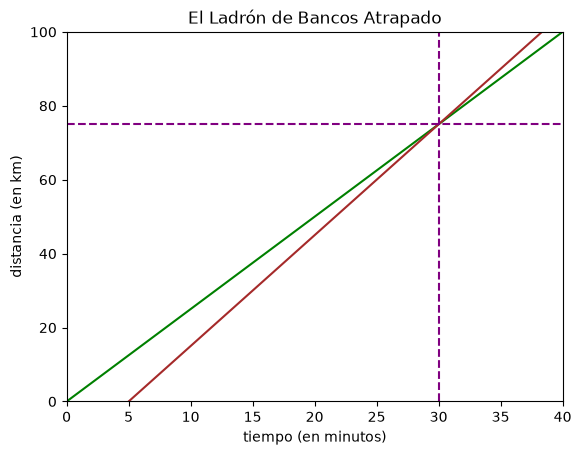

In [5]:
fig, ax = plt.subplots()
plt.title('El Ladrón de Bancos Atrapado')
plt.xlabel('tiempo (en minutos)')
plt.ylabel('distancia (en km)')
ax.set_xlim([0, 40])
ax.set_ylim([0, 100])
ax.plot(t, d_r, c='green')
ax.plot(t, d_s, c='brown')
plt.axvline(x=30, color='purple', linestyle='--')
_ = plt.axhline(y=75, color='purple', linestyle='--')

El sheriff consigue atrapar al ladrón a los **30 minutos**, cuando ambos han recorrido **75 km**. Ese punto $(t, d) = (30, 75)$ es precisamente la intersección de las dos rectas, es decir, la solución del sistema de dos ecuaciones lineales con dos incógnitas que hemos representado gráficamente.

**Volvemos a las slides.**

### Escalares (Tensores de Rango 0) en bases de Python

Un **escalar** es un único número, sin dirección ni componentes adicionales. En la jerga de tensores, es un **tensor de rango 0** (0 dimensiones/ejes): no tiene ni filas ni columnas, simplemente *es* un valor.

Empezaremos viendo cómo se comportan los escalares usando los tipos nativos de Python (`int`, `float`), antes de pasar a las librerías numéricas especializadas (NumPy, PyTorch, TensorFlow).

A modo de contraste (lo veremos en detalle más adelante): un **vector** sí tiene dirección y varias componentes. Por ejemplo, un vector de 2 elementos, como $[3, 4]$, representa un punto (o una flecha desde el origen) en un espacio de 2 dimensiones. La diferencia clave con el escalar es precisamente el número de componentes/dimensiones.

In [6]:
x = 25
x

25

In [7]:
type(x) # si queremos más especificidad (por ejemplo, int16, uint8), necesitamos NumPy u otra librería numérica

int

In [8]:
y = 3

In [9]:
py_sum = x + y
py_sum

28

In [10]:
type(py_sum)

int

In [11]:
x_float = 25.0
float_sum = x_float + y
float_sum

28.0

In [12]:
type(float_sum)

float

Como es habitual en Python (y en la mayoría de lenguajes), al operar un `int` con un `float` el resultado se **promociona** automáticamente a `float` (`float_sum` es `float` aunque `y` sea `int`). Esta regla de *type promotion* es importante tenerla en mente porque, como veremos, NumPy, PyTorch y TensorFlow siguen convenciones similares (aunque a veces más estrictas) para mezclar tipos dentro de un mismo tensor.

### Escalares en PyTorch

* PyTorch y TensorFlow son las dos librerías de *diferenciación automática* más populares (un foco de los temas [*Cálculo I*](https://github.com/joanby/matematicas-ml/blob/master/notebooks/3-calculus-i.ipynb) y [*Cálculo II*](https://github.com/joanby/matematicas-ml/blob/master/notebooks/4-calculus-ii.ipynb) de la serie *Fundamentos de ML*) en Python, a su vez el lenguaje de programación más popular en ML.
* Los tensores de PyTorch están diseñados para ser pitónicos, es decir, para sentirse y comportarse como las matrices de NumPy.
* La ventaja de los tensores de PyTorch respecto a los arrays de NumPy es que se pueden usar fácilmente para operaciones en la GPU (ver [aquí](https://pytorch.org/tutorials/beginner/examples_tensor/two_layer_net_tensor.html) por ejemplo).
* La documentación sobre los tensores de PyTorch, incluyendo los tipos de datos disponibles, está [aquí](https://pytorch.org/docs/stable/tensors.html).

In [13]:
import torch

In [14]:
x_pt = torch.tensor(25) # especificación de tipo opcional, por ejemplo: dtype=torch.float16
x_pt

tensor(25)

In [15]:
x_pt.shape

torch.Size([])

### Escalares en TensorFlow (versión 2.0 o posterior)

Tensores creados con una envoltura, todo lo cual [se puede leer aquí](https://www.tensorflow.org/guide/tensor):  

* `tf.Variable`
* `tf.constant`
* `tf.placeholder`
* `tf.SparseTensor`

El más utilizado es `tf.Variable`, que usaremos aquí.

Al igual que con los tensores TF, en PyTorch podemos realizar operaciones similares, y podemos convertir fácilmente a y desde arrays NumPy.

Además, una lista completa de los tipos de datos de los tensores está disponible [aquí](https://www.tensorflow.org/api_docs/python/tf/dtypes/DType).

In [16]:
import tensorflow as tf

I0000 00:00:1788001899.594371    9667 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788001899.900368    9667 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788001901.142725    9667 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788001901.144469    9667 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will 

In [17]:
x_tf = tf.Variable(25, dtype=tf.int16) # dtype es opcional
x_tf

E0000 00:00:1788001901.357914    9667 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


<tf.Variable 'Variable:0' shape=() dtype=int16, numpy=25>

In [18]:
x_tf.shape

TensorShape([])

In [19]:
y_tf = tf.Variable(3, dtype=tf.int16)

In [20]:
x_tf + y_tf

<tf.Tensor: shape=(), dtype=int16, numpy=28>

In [21]:
tf_sum = tf.add(x_tf, y_tf)
tf_sum

<tf.Tensor: shape=(), dtype=int16, numpy=28>

In [24]:
tf_sum.numpy() # veamos que las operaciones NumPy convierten automáticamente los tensores en matrices NumPy, y viceversa

np.int16(28)

In [28]:
type(tf_sum.numpy())

numpy.int16

In [29]:
tf_float = tf.Variable(25., dtype=tf.float16)
tf_float

E0000 00:00:1788001912.804212    9667 util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


<tf.Variable 'Variable:0' shape=() dtype=float16, numpy=25.0>

**Volvemos a las slides aquí.**

### Vectores (Tensores de rango 1) en NumPy

Un **vector** es un *tensor de rango 1*: un array ordenado y unidimensional de números. Cada número del array es una **componente** (o *feature*) del vector, y el número total de componentes es su **dimensión**.

Geométricamente, un vector puede interpretarse de dos formas equivalentes:

* como un **punto** en un espacio de $n$ dimensiones, o
* como una **flecha** que va desde el origen $(0, 0, \dots, 0)$ hasta ese punto.

Notación habitual: se suele escribir en minúscula y negrita, $\mathbf{x}$, y sus componentes con subíndices, $\mathbf{x} = [x_1, x_2, \dots, x_n]$. En Python, salvo que se indique lo contrario, representaremos los vectores como **vectores columna** cuando participen en operaciones matriciales.

In [30]:
import numpy as np

In [33]:
x = np.array([25, 2, 5]) # el parámetro type es opcional, p.ej.: dtype=np.float16
x

array([25,  2,  5])

In [34]:
len(x)

3

In [35]:
x.shape

(3,)

El `shape` de un vector de NumPy es una tupla con un único elemento, por ejemplo `(3,)`: el número de componentes. Esa forma «plana» (sin fila ni columna explícita) es la razón por la que, como veremos a continuación, transponer un vector 1-D no tiene ningún efecto visible.

In [36]:
type(x)

numpy.ndarray

In [37]:
x[0] # zero-indexed

np.int64(25)

In [38]:
type(x[0])

numpy.int64

### Transposición de Vectores

La **transposición** convierte un vector fila en un vector columna (y viceversa), y se denota con el superíndice $T$: $\mathbf{x}^T$. Formalmente, si $\mathbf{x}$ es un vector columna de $n$ componentes (forma $n \times 1$), su transpuesto $\mathbf{x}^T$ es un vector fila con la misma información (forma $1 \times n$).

En NumPy esto se aprecia claramente sólo cuando el vector está representado como una matriz de una fila o una columna (es decir, con dos dimensiones expresadas mediante corchetes anidados); un array 1-D «plano» no tiene fila ni columna que intercambiar, así que `.T` no cambia nada, como veremos a continuación.

In [40]:
# Transponer un array 1-D normal no tiene ningún efecto...
x_t = x.T
x_t

array([25,  2,  5])

In [41]:
x_t.shape

(3,)

In [42]:
# ...pero sí cuando utilizamos paréntesis anidados «tipo matriz»:
y = np.array([[25, 2, 5], [4, 5, 6]])
y

array([[25,  2,  5],
       [ 4,  5,  6]])

In [43]:
y.shape

(2, 3)

In [44]:
# ...pero se puede transponer una matriz de dimensión 1, lo que equivale matemáticamente a:
y_t = y.T
y_t

array([[25,  4],
       [ 2,  5],
       [ 5,  6]])

In [45]:
y_t.shape # Esto es un vector columna ya que tiene 3 filas y 1 columna

(3, 2)

In [46]:
# El vector columna puede transponerse al vector fila original:
y_t.T

array([[25,  2,  5],
       [ 4,  5,  6]])

In [47]:
y_t.T.shape

(2, 3)

### Vectores nulos

El **vector nulo** (o vector cero), denotado $\mathbf{0}$, es aquel cuyas componentes son todas cero: $\mathbf{0} = [0, 0, \dots, 0]$. Es el **elemento neutro** de la suma de vectores: sumarlo a cualquier otro vector $\mathbf{x}$ lo deja inalterado, $\mathbf{x} + \mathbf{0} = \mathbf{x}$.

In [48]:
z = np.zeros(3)
z

array([0., 0., 0.])

### Vectores en PyTorch y TensorFlow

Al igual que con los escalares, la sintaxis para crear vectores es prácticamente idéntica a la de NumPy:

In [49]:
x_pt = torch.tensor([25, 2, 5])
x_pt

tensor([25,  2,  5])

In [50]:
x_tf = tf.Variable([25, 2, 5])
x_tf

<tf.Variable 'Variable:0' shape=(3,) dtype=int32, numpy=array([25,  2,  5], dtype=int32)>

**Volver a las slides aquí.**

### Norma $L^2$

La **norma $L^2$** (o norma euclídea) de un vector $\mathbf{x}$ se define como:

$$\|\mathbf{x}\|_2 = \sqrt{\sum_{i} x_i^2}$$

Mide la distancia en línea recta (distancia euclídea) desde el origen hasta el punto que representa el vector — es una aplicación directa del teorema de Pitágoras en $n$ dimensiones. Es la norma más habitual en Machine Learning, tanto que cuando se habla de «la norma» de un vector sin más especificación, casi siempre se refiere a esta.

In [51]:
x

array([25,  2,  5])

In [53]:
(25**2 + 2**2 + 5**2)**(1/2)

25.573423705088842

In [54]:
np.linalg.norm(x)

np.float64(25.573423705088842)

Así, si las unidades en este espacio vectorial tridimensional son metros, entonces el vector $x$ tiene una longitud de 25.6m

**Volver a las slides aquí.**

### Norma $L^1$

La **norma $L^1$** se define como la suma de los valores absolutos de las componentes:

$$\|\mathbf{x}\|_1 = \sum_{i} |x_i|$$

A diferencia de la norma $L^2$, crece a un ritmo constante en cualquier dirección, por lo que es especialmente útil cuando la diferencia entre que un valor sea exactamente cero o simplemente muy pequeño (distinto de cero) es importante — por ejemplo, para fomentar la dispersión (*sparsity*) de un vector de coeficientes, como en la regularización Lasso.

In [55]:
x

array([25,  2,  5])

In [56]:
np.abs(25) + np.abs(2) + np.abs(5)

np.int64(32)

**Volver a las slides aquí.**

### Norma $L^2$ al Cuadrado

La **norma $L^2$ al cuadrado** es, como su nombre indica, el cuadrado de la norma euclídea:

$$\|\mathbf{x}\|_2^2 = \sum_i x_i^2 = \mathbf{x}^T\mathbf{x}$$

Es equivalente al producto escalar de un vector consigo mismo. Al eliminar la raíz cuadrada resulta más ligera computacionalmente (y su gradiente es mucho más simple, algo relevante para el descenso de gradiente). Sin embargo, cerca del origen crece muy despacio, lo que la hace poco adecuada cuando es importante distinguir bien entre un valor exactamente cero y otro simplemente muy pequeño.

In [57]:
x

array([25,  2,  5])

In [58]:
(25**2 + 2**2 + 5**2)

654

In [59]:
# Cubriremos la multiplicación tensorial más pronto pero para probar el producto escalar rápidamente:
np.dot(x, x)

np.int64(654)

**Volver a las slides aquí.**

### Norma del Máximo

La **norma del máximo** (o norma $L^\infty$, también llamada norma de Chebyshev) se define como:

$$\|\mathbf{x}\|_\infty = \max_i |x_i|$$

Es decir, devuelve simplemente el valor absoluto de la componente de mayor magnitud del vector.

In [60]:
x

array([25,  2,  5])

In [61]:
np.abs(np.max(x))

np.int64(25)

**Volver a las slides aquí.**

Las normas $L^1$ y $L^2$ son las que más se usan para **regularizar** funciones objetivo, básicamente para evitar el *overfitting* penalizando la magnitud de los coeficientes del modelo:

* **Lasso** (regularización $L^1$): al fomentar coeficientes exactamente iguales a 0, resulta ideal para la **selección de features**, especialmente en datos de alta dimensionalidad.
* **Ridge** (regularización $L^2$): en lugar de anular coeficientes, los reduce de forma suave, y funciona especialmente bien cuando las variables independientes están **altamente correlacionadas** entre sí.
* **Elastic Net** combina ambas penalizaciones ($L^1$ + $L^2$) para aprovechar las ventajas de las dos.

### Bases

Una **base** de un espacio vectorial es un conjunto de vectores **linealmente independientes** que, combinados mediante sumas y multiplicaciones por escalares (es decir, mediante **combinaciones lineales**), permiten generar (representar) *cualquier* vector de ese espacio.

Por ejemplo, los vectores $[1, 0]$ y $[0, 1]$ forman una base del espacio de 2 dimensiones $\mathbb{R}^2$: cualquier vector bidimensional $[a, b]$ puede escribirse como la combinación lineal $a\cdot[1,0] + b\cdot[0,1]$. A esta base en particular, formada por vectores unitarios y ortogonales entre sí, se la llama **base estándar** (o base canónica).

### Vectores Ortogonales y Ortonormales

Dos vectores son **ortogonales** si su producto escalar es 0: $\mathbf{x} \cdot \mathbf{y} = 0$. Geométricamente esto significa que forman un ángulo de 90º entre sí, es decir, son perpendiculares.

Un conjunto de vectores es **ortonormal** cuando, además de ser ortogonales entre sí dos a dos, cada uno de ellos tiene **norma unitaria** ($\|\mathbf{x}\|_2 = 1$). La base estándar que vimos antes, $[1,0]$ y $[0,1]$, es un ejemplo de conjunto ortonormal.

In [62]:
i = np.array([1, 0])
i

array([1, 0])

In [63]:
j = np.array([0, 1])
j

array([0, 1])

In [64]:
np.dot(i, j) # detalles en el producto escalar próximamente...

np.int64(0)

**Volver a las slides aquí.**

### Matrices (Tensores de Rango 2) en NumPy

Una **matriz** es un *tensor de rango 2*: un array bidimensional de números organizados en **filas** y **columnas**. Se denota habitualmente con una letra mayúscula (por ejemplo $X$), y su tamaño (forma) se expresa como *filas* $\times$ *columnas*, $m \times n$.

Cada elemento se identifica por dos índices, fila y columna: $X_{i,j}$ es el elemento de la fila $i$, columna $j$.

In [65]:
# Usamos array() con corchetes anidados:
X = np.array([[25, 2], [5, 26], [3, 7]])
X

array([[25,  2],
       [ 5, 26],
       [ 3,  7]])

In [66]:
X.shape

(3, 2)

In [67]:
X.size

6

In [68]:
# Seleccionamos la columna izquierda de la matriz X (índice cero)
X[:,0]

array([25,  5,  3])

In [69]:
# Seleccionamos la fila del medio de la matriz:
X[1,:]

array([ 5, 26])

In [70]:
# Otro ejemplo de slicing-by-index:
X[0:2, 0:2]

array([[25,  2],
       [ 5, 26]])

### Matrices en PyTorch

La sintaxis es, de nuevo, muy similar a la de NumPy:

In [71]:
X_pt = torch.tensor([[25, 2], [5, 26], [3, 7]])
X_pt

tensor([[25,  2],
        [ 5, 26],
        [ 3,  7]])

In [72]:
X_pt.shape # pythonico relativo a PyTorch

torch.Size([3, 2])

In [73]:
X_pt[1,:] # N.B.: Python se basa en índices que empiezan en cero; el álgebra se basa en índice que empieza en 1

tensor([ 5, 26])

### Matrices en TensorFlow

Y lo mismo ocurre con TensorFlow:

In [74]:
X_tf = tf.Variable([[25, 2], [5, 26], [3, 7]])
X_tf

<tf.Variable 'Variable:0' shape=(3, 2) dtype=int32, numpy=
array([[25,  2],
       [ 5, 26],
       [ 3,  7]], dtype=int32)>

In [75]:
tf.rank(X_tf) # devuelve el numero de dimensiones

<tf.Tensor: shape=(), dtype=int32, numpy=2>

In [76]:
tf.shape(X_tf)

<tf.Tensor: shape=(2,), dtype=int32, numpy=array([3, 2], dtype=int32)>

In [77]:
X_tf[1,:]

<tf.Tensor: shape=(2,), dtype=int32, numpy=array([ 5, 26], dtype=int32)>

**Volver a las slides aquí.**

### Tensores de Rango Superior

Como ejemplo, los tensores de rango 4 son comunes para las imágenes, donde cada dimensión corresponde a:

1. Número de imágenes en el lote de entrenamiento, por ejemplo, 32
2. Altura de la imagen en píxeles, por ejemplo, 28 para [MNIST digits](http://yann.lecun.com/exdb/mnist/)
3. Anchura de la imagen en píxeles, p. ej., 28
4. Número de canales de color, por ejemplo, 3 para imágenes a todo color (RGB)

In [78]:
images_pt = torch.zeros([32, 28, 28, 3])

In [ ]:
# images_pt

tensor([[[[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.],
          ...,
          [0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]],

         [[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.],
          ...,
          [0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]],

         [[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.],
          ...,
          [0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]],

         ...,

         [[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.],
          ...,
          [0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]],

         [[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.],
          ...,
          [0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]],

         [[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.],
          ...,
          [0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]]],


        [[[0., 0.

In [80]:
images_tf = tf.zeros([32, 28, 28, 3])

In [ ]:
# images_tf

<tf.Tensor: shape=(32, 28, 28, 3), dtype=float32, numpy=
array([[[[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        ...,

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]],


   

**Volver a las slides aquí.**

## Segmento 2: Operaciones con Tensores más comunes

En este segmento veremos las operaciones más habituales que se aplican sobre tensores (vectores, matrices y tensores de mayor rango): la transposición, la aritmética básica elemento a elemento, las reducciones (como la suma), el producto escalar (o producto punto) y, para cerrar, cómo resolver sistemas de ecuaciones lineales de forma gráfica — la antesala de los métodos matriciales que veremos en el Segmento 3.

### Transposición de Tensores

La transposición de una matriz es una operación matemática que consiste en intercambiar sus filas por columnas. Al hacer esto, una matriz original de dimensiones $m \times n$ se convierte en una nueva matriz (generalmente denotada como $A^T$) de dimensiones $n \times m$, donde cada elemento de la posición $(i, j)$ pasa a ocupar la posición $(j, i)$.

Es una operación **involutiva**: transponer dos veces devuelve la matriz original, $(A^T)^T = A$.

In [81]:
X

array([[25,  2],
       [ 5, 26],
       [ 3,  7]])

In [82]:
X.T

array([[25,  5,  3],
       [ 2, 26,  7]])

In [83]:
X_pt.T

tensor([[25,  5,  3],
        [ 2, 26,  7]])

In [85]:
tf.transpose(X_tf) # menos Pythonico

<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
array([[25,  5,  3],
       [ 2, 26,  7]], dtype=int32)>

### Propiedades Aritméticas Básicas


Al sumar o multiplicar un tensor por un escalar, la operación se aplica a **todos los elementos por igual** y se conserva la forma (*shape*) del tensor. Por ejemplo, para una matriz $X$ y un escalar $\alpha$:

$$ (X + \alpha)_{i,j} = X_{i,j} + \alpha \qquad (\alpha X)_{i,j} = \alpha \, X_{i,j} $$

In [86]:
X

array([[25,  2],
       [ 5, 26],
       [ 3,  7]])

In [87]:
X*2

array([[50,  4],
       [10, 52],
       [ 6, 14]])

In [88]:
X+2

array([[27,  4],
       [ 7, 28],
       [ 5,  9]])

In [89]:
X*2+2

array([[52,  6],
       [12, 54],
       [ 8, 16]])

In [90]:
X_pt*2+2 # Los operadores de Python están sobrecargados; también podemos utilizar torch.mul() o torch.add()

tensor([[52,  6],
        [12, 54],
        [ 8, 16]])

In [91]:
torch.add(torch.mul(X_pt, 2), 2)

tensor([[52,  6],
        [12, 54],
        [ 8, 16]])

In [92]:
X_tf*2+2 # Operadores igualmente sobrecargados; podríamos utilizar igualmente tf.multiply() tf.add()

<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
array([[52,  6],
       [12, 54],
       [ 8, 16]], dtype=int32)>

In [93]:
tf.add(tf.multiply(X_tf, 2), 2)

<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
array([[52,  6],
       [12, 54],
       [ 8, 16]], dtype=int32)>

Si dos tensores tienen el mismo tamaño, las operaciones se suelen aplicar por defecto de forma elemental. No se trata de **multiplicación de matrices**, que veremos más adelante, sino que se denomina **producto de Hadamard** o simplemente **producto elemento a elemento**.

La notación matemática es $A \odot X$, y componente a componente: $(A \odot X)_{i,j} = A_{i,j} \cdot X_{i,j}$. A diferencia de la multiplicación de matrices, el producto de Hadamard exige que ambos tensores tengan **exactamente la misma forma**.

In [94]:
X

array([[25,  2],
       [ 5, 26],
       [ 3,  7]])

In [95]:
A = X+2
A

array([[27,  4],
       [ 7, 28],
       [ 5,  9]])

In [96]:
A + X

array([[52,  6],
       [12, 54],
       [ 8, 16]])

In [97]:
A * X

array([[675,   8],
       [ 35, 728],
       [ 15,  63]])

In [98]:
A_pt = X_pt + 2

In [99]:
A_pt + X_pt

tensor([[52,  6],
        [12, 54],
        [ 8, 16]])

In [100]:
A_pt * X_pt

tensor([[675,   8],
        [ 35, 728],
        [ 15,  63]])

In [101]:
A_tf = X_tf + 2

In [102]:
A_tf + X_tf

<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
array([[52,  6],
       [12, 54],
       [ 8, 16]], dtype=int32)>

In [103]:
A_tf * X_tf

<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
array([[675,   8],
       [ 35, 728],
       [ 15,  63]], dtype=int32)>

### Reducción

Calcular la suma de todos los elementos de un tensor es una operación habitual. Por ejemplo:

* Para un vector ***x*** de longitud *n*, calculamos $\sum_{i=1}^{n} x_i$.
* Para la matriz ***X*** con *m* por *n* dimensiones, calculamos $\sum_{i=1}^{m} \sum_{j=1}^{n} X_{i,j}$

In [104]:
X

array([[25,  2],
       [ 5, 26],
       [ 3,  7]])

In [105]:
X.sum()

np.int64(68)

In [106]:
torch.sum(X_pt)

tensor(68)

In [108]:
tf.reduce_sum(X_tf)

<tf.Tensor: shape=(), dtype=int32, numpy=68>

In [ ]:
# También puede hacerse a lo largo de un solo eje específico, por ejemplo:
X.sum(axis=0) # sumar sobre todas las filas, es decir coger la columna 0 y sumar todos sus elementos, la columna 1 y sumar todos sus elementos, y así sucesivamente. La suma se hace en vertical

array([33, 35])

In [ ]:
X.sum(axis=1) # sumar sobre todas las columnas, la suma se hace en horizontal se coge la fila 0 y se suman todos los elementos, asi con la 1, 2, etc. 

array([27, 31, 10])

In [111]:
torch.sum(X_pt, 0)

tensor([33, 35])

In [112]:
tf.reduce_sum(X_tf, 1)

<tf.Tensor: shape=(3,), dtype=int32, numpy=array([27, 31, 10], dtype=int32)>

Pueden aplicarse muchas otras operaciones con reducción a lo largo de todos los ejes o de una selección de ellos, p. ej:

* máximo
* mínimo
* media
* producto

Son bastante sencillas y se utilizan con menos frecuencia que la suma, así que te invitamos a buscarlas en los documentos de la biblioteca si alguna vez las necesitas.

### El Producto Escalar

Si tenemos dos vectores (digamos, ***x*** y ***y***) con la misma longitud *n*, podemos calcular el producto punto entre ellos (también llamado **producto escalar**). Esto se anota de varias maneras diferentes, incluyendo las siguientes:

* $x \cdot y$
* $x^Ty$
* $\langle x,y \rangle$.

Independientemente de la notación que utilices (yo prefiero la primera), el cálculo es el mismo; calculamos los productos de una manera elemento a elemento y luego sumamos reductivamente a través de los productos a un valor escalar. Es decir, $x \cdot y = \sum_{i=1}^{n} x_i y_i$.

El producto punto es omnipresente en el aprendizaje profundo: se realiza en cada neurona artificial de una red neuronal profunda, que puede estar formada por millones (u órdenes de magnitud superiores) de estas neuronas. De hecho, la salida (antes de aplicar la función de activación) de una neurona con entradas $x$ y pesos $w$ es precisamente un producto punto más un sesgo: $z = w \cdot x + b$.

In [113]:
x

array([25,  2,  5])

In [116]:
y = np.array([0, 1, 2])
y

array([0, 1, 2])

In [117]:
25*0 + 2*1 + 5*2

12

In [ ]:
np.dot(x, y)

12

In [118]:
x_pt

tensor([25,  2,  5])

In [119]:
y_pt = torch.tensor([0, 1, 2])
y_pt

tensor([0, 1, 2])

In [120]:
np.dot(x_pt, y_pt)

/tmp/ipykernel_9667/91207232.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np.dot(x_pt, y_pt)


np.int64(12)

In [126]:
torch.dot(x_pt, y_pt)

tensor(12)

In [122]:
x_tf

<tf.Variable 'Variable:0' shape=(3,) dtype=int32, numpy=array([25,  2,  5], dtype=int32)>

In [123]:
y_tf = tf.Variable([0, 1, 2])
y_tf

<tf.Variable 'Variable:0' shape=(3,) dtype=int32, numpy=array([0, 1, 2], dtype=int32)>

In [124]:
tf.reduce_sum(tf.multiply(x_tf, y_tf))

<tf.Tensor: shape=(), dtype=int32, numpy=12>

**Volver a las slides aquí.**

### Resolución de Sistemas Lineales

En el ejemplo de **Sustitución**, las dos ecuaciones del sistema son:
$$ y = 3x $$
$$ -5x + 2y = 2 $$

La segunda ecuación puede reordenarse para aislar $y$:
$$ 2y = 2 + 5x $$
$$ y = \frac{2 + 5x}{2} = 1 + \frac{5x}{2} $$

Representemos gráficamente ambas rectas: el punto donde se cruzan es la solución $(x, y)$ del sistema.

In [141]:
x = np.linspace(-10, 10, 1000) # inicio, final, n puntos

In [142]:
y1 = 3 * x

In [143]:
y2 = 1 + (5*x)/2

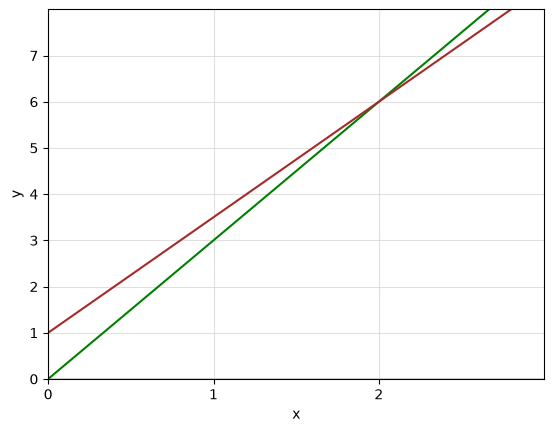

In [145]:
fig, ax = plt.subplots()
plt.xlabel('x')
plt.ylabel('y')

# Añadimos los ejes x e y:
plt.axvline(x=0, color='lightgray')
plt.axhline(y=0, color='lightgray')

ax.set_xlim([0, 3])
ax.set_ylim([0, 8])
ax.set_xticks(np.arange(0, 3, 1))  # saltos de 1 en 1 en el eje x
ax.set_yticks(np.arange(0, 8, 1))   # saltos de 1 en 1 en el eje y
ax.grid(True, color='lightgray', alpha=0.7)  # cuadrícula de fondo
ax.plot(x, y1, c='green')
ax.plot(x, y2, c='brown')

**Volver a las slides aquí.**

En el ejemplo de **Eliminación**, las dos ecuaciones del sistema son:
$$ 2x - 3y = 15 $$
$$ 4x + 10y = 14 $$

Ambas ecuaciones pueden reordenarse para aislar $y$. A partir de la primera ecuación:
$$ -3y = 15 - 2x $$
$$ y = \frac{15 - 2x}{-3} = -5 + \frac{2x}{3} $$

Si operamos con la segunda ecuación:
$$ 4x + 10y = 14 $$
$$ 2x + 5y = 7 $$
$$ 5y = 7 - 2x $$
$$ y = \frac{7 - 2x}{5} $$

Como antes, representamos gráficamente ambas rectas: la intersección nos da la solución del sistema.

In [133]:
y1 = -5 + (2*x)/3

In [134]:
y2 = (7-2*x)/5

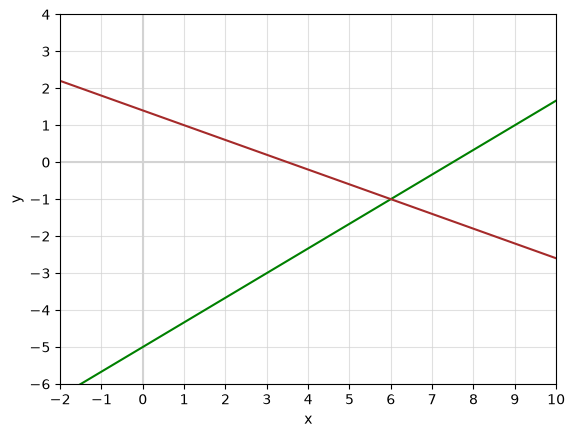

In [139]:
fig, ax = plt.subplots()
plt.xlabel('x')
plt.ylabel('y')

# Añadimos los ejes x e y:
plt.axvline(x=0, color='lightgray')
plt.axhline(y=0, color='lightgray')

ax.set_xlim([-2, 10])
ax.set_ylim([-6, 4])
ax.set_xticks(np.arange(-2, 11, 1))  # saltos de 1 en 1 en el eje x
ax.set_yticks(np.arange(-6, 5, 1))   # saltos de 1 en 1 en el eje y
ax.grid(True, color='lightgray', alpha=0.7)  # cuadrícula de fondo
ax.plot(x, y1, c='green')
ax.plot(x, y2, c='brown')

**Volver a las slides aquí.**

## Segmento 3: Propiedades de las Matrices

In [1]:
import numpy as np
import torch
import tensorflow as tf

I0000 00:00:1788094243.334507   13600 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788094243.373964   13600 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788094244.380939   13600 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788094244.381273   13600 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will 

### La Norma de Frobenius

La norma de Frobenius es una medida matemática de "tamaño" o "magnitud" para matrices, siendo la extensión natural de la distancia euclidiana (la longitud estándar de un vector) aplicada al formato bidimensional de una matriz:

$$ \|A\|_F = \sqrt{\sum_{i,j} A_{i,j}^2} $$

Uso en Machine Learning: es extremadamente popular en algoritmos de optimización, compresión de imágenes, sistemas de recomendación y factorización de matrices (como *Principal Component Analysis* o PCA), donde el objetivo suele ser minimizar la diferencia (el error) entre una matriz real y su aproximación computacional.

In [2]:
X = np.array([[1, 2], [3, 4]])
X

array([[1, 2],
       [3, 4]])

In [3]:
(1**2 + 2**2 + 3**2 + 4**2)**(1/2)

5.477225575051661

In [4]:
np.linalg.norm(X) # la misma función que para la norma vectorial L2

np.float64(5.477225575051661)

In [5]:
X_pt = torch.tensor([[1, 2], [3, 4.]]) # torch.norm() solamente soporta floats

In [6]:
torch.norm(X_pt)

tensor(5.4772)

In [7]:
X_tf = tf.Variable([[1, 2], [3, 4.]]) # tf.norm() solamente soporta floats

E0000 00:00:1788094251.188676   13600 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [9]:
tf.norm(X_tf)

<tf.Tensor: shape=(), dtype=float32, numpy=5.4772257804870605>

**Volver a las slides aquí.**

### Multiplicación de Matrices (por un Vector)

In [11]:
A = np.array([[3, 4], [5, 6], [7, 8]])
A

array([[3, 4],
       [5, 6],
       [7, 8]])

In [12]:
b = np.array([1, 2])
b

array([1, 2])

In [13]:
np.dot(A, b) # aunque técnicamente el producto punto es sólo entre vectores

array([11, 17, 23])

In [14]:
A_pt = torch.tensor([[3, 4], [5, 6], [7, 8]])
A_pt

tensor([[3, 4],
        [5, 6],
        [7, 8]])

In [15]:
b_pt = torch.tensor([1, 2])
b_pt

tensor([1, 2])

In [16]:
torch.matmul(A_pt, b_pt) # como np.dot(), infiere automáticamente las dimensiones para realizar producto punto, matvec, o multiplicación de matrices.

tensor([11, 17, 23])

In [18]:
A_tf = tf.Variable([[3, 4], [5, 6], [7, 8]])
A_tf

<tf.Variable 'Variable:0' shape=(3, 2) dtype=int32, numpy=
array([[3, 4],
       [5, 6],
       [7, 8]], dtype=int32)>

In [19]:
b_tf = tf.Variable([1, 2])
b_tf

<tf.Variable 'Variable:0' shape=(2,) dtype=int32, numpy=array([1, 2], dtype=int32)>

In [20]:
tf.linalg.matvec(A_tf, b_tf)

<tf.Tensor: shape=(3,), dtype=int32, numpy=array([11, 17, 23], dtype=int32)>

**Volver a las slides aquí.**

### Multiplicación de Matrices (con Dos Matrices)

In [21]:
A

array([[3, 4],
       [5, 6],
       [7, 8]])

In [22]:
B = np.array([[1, 9], [2, 0]])
B

array([[1, 9],
       [2, 0]])

In [23]:
np.dot(A, B)

array([[11, 27],
       [17, 45],
       [23, 63]])

Tenga en cuenta que la multiplicación de matrices no es "conmutativa" (es decir, $AB \neq BA$) por lo que al descomentar la línea siguiente se producirá un error de desajuste de tamaño:

In [ ]:
# np.dot(B, A)

In [24]:
B_pt = torch.from_numpy(B) # más limpia que la conversión de TF
B_pt

tensor([[1, 9],
        [2, 0]])

In [25]:
# otra forma de crear el mismo tensor con transposición:
B_pt = torch.tensor([[1, 2], [9, 0]]).T
B_pt

tensor([[1, 9],
        [2, 0]])

In [26]:
torch.matmul(A_pt, B_pt) # no se necesita cambiar la función, a diferencia de TF

tensor([[11, 27],
        [17, 45],
        [23, 63]])

In [27]:
B_tf = tf.convert_to_tensor(B, dtype=tf.int32)
B_tf

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[1, 9],
       [2, 0]], dtype=int32)>

In [28]:
tf.matmul(A_tf, B_tf)

<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
array([[11, 27],
       [17, 45],
       [23, 63]], dtype=int32)>

**Volver a las slides aquí.**

### Matrices Simétricas

Una matriz $A$ es **simétrica** si es igual a su propia transpuesta:

$$ A = A^T $$

Es decir, el elemento $A_{i,j}$ coincide siempre con $A_{j,i}$ (es simétrica «respecto a la diagonal principal»). Las matrices simétricas aparecen constantemente en Machine Learning: por ejemplo, $X^TX$ (la que usamos para resolver la regresión lineal en la ecuación normal) es siempre simétrica, sea cual sea $X$.

In [27]:
X_sym = np.array([[0, 1, 2], [1, 7, 8], [2, 8, 9]])
X_sym

array([[0, 1, 2],
       [1, 7, 8],
       [2, 8, 9]])

In [28]:
X_sym.T

array([[0, 1, 2],
       [1, 7, 8],
       [2, 8, 9]])

In [29]:
X_sym.T == X_sym

array([[ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True]])

**Volver a las slides aquí.**

### Matrices Identidad

In [29]:
I = torch.tensor([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
I

tensor([[1, 0, 0],
        [0, 1, 0],
        [0, 0, 1]])

In [30]:
x_pt = torch.tensor([25, 2, 5])
x_pt

tensor([25,  2,  5])

In [31]:
torch.matmul(I, x_pt)

tensor([25,  2,  5])

**Volver a las slides aquí.**

### Inversión de Matrices

La inversa de una matriz $A$, denotada $A^{-1}$, es la matriz que al multiplicarla por la original devuelve la matriz identidad:

$$ AA^{-1} = A^{-1}A = I $$

Es el equivalente matricial de «dividir entre $A$», y es precisamente lo que nos permite despejar $w$ en un sistema $Xw = y$ (como hicimos en el ejemplo de regresión al final del notebook).

In [41]:
X = np.array([[4, 2], [-5, -3]])
X

array([[ 4,  2],
       [-5, -3]])

In [42]:
Xinv = np.linalg.inv(X)
Xinv

array([[ 1.5,  1. ],
       [-2.5, -2. ]])

Como un rápido aporte, vamos a demostrar que $X^{-1}X = I_n$ según las diapositivas:

In [43]:
np.round(np.dot(Xinv, X))

array([[1., 0.],
       [0., 1.]])

...y ahora volvemos a resolver las incógnitas en $w$:

In [44]:
y = np.array([4, -7])
y

array([ 4, -7])

In [45]:
w = np.dot(Xinv, y)
w

array([-1.,  4.])

De modo que $y = Xw$:

In [40]:
np.dot(X, w)

array([ 4., -7.])

**Visualización Geométrica**

Recordando de las diapositivas que las dos ecuaciones del sistema son:
$$ 4b + 2c = 4 $$
$$ -5b - 3c = -7 $$

Ambas ecuaciones pueden reordenarse para aislar una variable, digamos $c$. A partir de la primera ecuación:
$$ 4b + 2c = 4 $$
$$ 2b + c = 2 $$
$$ c = 2 - 2b $$

Entonces para la segunda ecuación:
$$ -5b - 3c = -7 $$
$$ -3c = -7 + 5b $$
$$ c = \frac{-7 + 5b}{-3} = \frac{7 - 5b}{3} $$

In [43]:
b = np.linspace(-10, 10, 1000) # inicio, final, n puntos

In [44]:
c1 = 2 - 2*b

In [45]:
c2 = (7-5*b)/3

In [47]:
import matplotlib.pyplot as plt

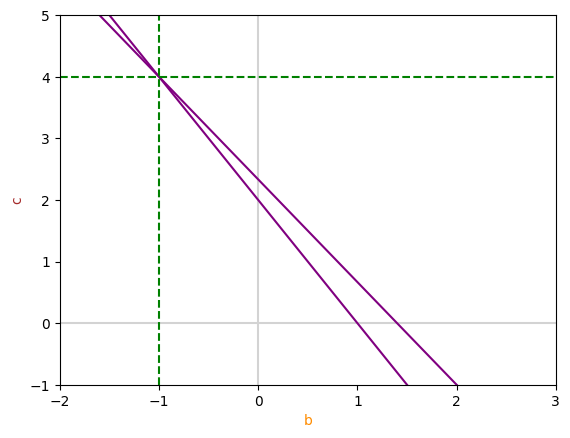

In [48]:
fig, ax = plt.subplots()
plt.xlabel('b', c='darkorange')
plt.ylabel('c', c='brown')

plt.axvline(x=0, color='lightgray')
plt.axhline(y=0, color='lightgray')

ax.set_xlim([-2, 3])
ax.set_ylim([-1, 5])
ax.plot(b, c1, c='purple')
ax.plot(b, c2, c='purple')
plt.axvline(x=-1, color='green', linestyle='--')
_ = plt.axhline(y=4, color='green', linestyle='--')

En PyTorch y TensorFlow:

In [49]:
torch.inverse(torch.tensor([[4, 2], [-5, -3.]])) # tipo float

tensor([[ 1.5000,  1.0000],
        [-2.5000, -2.0000]])

In [50]:
tf.linalg.inv(tf.Variable([[4, 2], [-5, -3.]])) # también float

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[ 1.4999998,  0.9999998],
       [-2.4999995, -1.9999996]], dtype=float32)>

**Volver a las slides aquí.**

### Inversión de la matriz cuando no hay solución

Todas las columnas deben ser linealmente independientes para que la matriz tenga inversa, y la matriz debe ser cuadrada (mismo número de filas y columnas).

In [51]:
X = np.array([[-4, 1], [-8, 2]])
X

array([[-4,  1],
       [-8,  2]])

In [52]:
# Descomentar la línea siguiente da lugar a un error de "matriz singular
# Xinv = np.linalg.inv(X)

LinAlgError: Singular matrix

Siéntase libre de intentar invertir una matriz no cuadrada; esto también arrojará un error.

**Vuelve a las slides aquí.**

### Matrices diagonales

Son matrices en las que todos los valores son 0 excepto los de la diagonal principal; la matriz identidad es un caso particular, aunque la diagonal puede contener cualquier otro valor y seguiría siendo una matriz diagonal.

Su gran ventaja es que son muy baratas de operar: multiplicar o invertir una matriz diagonal sólo implica trabajar con esos pocos valores de la diagonal, sin tocar el resto de la matriz (que ya sabemos que son ceros).

In [1]:
D = np.diag([2, 5, 3])
D

array([[2, 0, 0],
       [0, 5, 0],
       [0, 0, 3]])

In [2]:
np.linalg.inv(D)  # la inversa de una diagonal es, sencillamente, 1 dividido entre cada elemento de la diagonal

array([[0.5       , 0.        , 0.        ],
       [0.        , 0.2       , 0.        ],
       [0.        , 0.        , 0.33333333]])

### Matrices Ortogonales

Recordemos que dos vectores son **ortogonales** si su producto escalar es 0, y **ortonormales** si además cada uno tiene norma unitaria (longitud 1).

Una matriz $Q$ es **ortogonal** cuando todas sus columnas son vectores ortonormales entre sí. La propiedad que las hace tan útiles es que su inversa coincide con su transpuesta:

$$ Q^{-1} = Q^T \quad\Longleftrightarrow\quad Q^TQ = QQ^T = I $$

Esto es una gran ventaja computacional: transponer una matriz es trivial (barato), mientras que invertir una matriz en general no lo es.

**¿Cómo identificamos si una matriz es ortogonal?** Basta con comprobar que $Q^TQ$ da la matriz identidad (de forma equivalente: que sus columnas son perpendiculares entre sí y cada una mide 1). Veámoslo con el ejemplo más sencillo posible: una **rotación de 90°**.

In [1]:
import numpy as np

# Matriz de rotación de 90°: un ejemplo clásico de matriz ortogonal
Q = np.array([[0, -1],
              [1,  0]])
Q

array([[ 0, -1],
       [ 1,  0]])

In [2]:
Q.T @ Q

array([[1, 0],
       [0, 1]])

Efectivamente, $Q^TQ = I$: las columnas de $Q$ son ortonormales, así que $Q$ es ortogonal — y su inversa es, directamente, $Q^T$, sin necesidad de calcular ninguna inversa.

**¿Para qué se usan?** Las matrices ortogonales representan transformaciones que **preservan longitudes y ángulos** (rotaciones y reflexiones): al aplicar $Q$ a un vector, el resultado gira o refleja el vector pero no lo deforma ni cambia su tamaño. Por eso son la base de las rotaciones en gráficos por ordenador y robótica, y aparecen en factorizaciones matriciales como la **QR** o la **SVD** (que veremos en *Álgebra Lineal II*), muy usadas para resolver sistemas de forma numéricamente estable y para reducir la dimensionalidad de los datos (PCA).

In [3]:
v = np.array([3, 4])
print("Norma antes de rotar: ", np.linalg.norm(v))
print("Norma después de rotar:", np.linalg.norm(Q @ v))

Norma antes de rotar:  5.0
Norma después de rotar: 5.0

Como se ve, la norma del vector no cambia al rotarlo con $Q$ — esa es, en esencia, la propiedad que define a una matriz ortogonal.

**Volver a las slides aquí.**

## Aplicación Práctica: Regresión Lineal para Predecir Precios de Casas

Cerramos el tema aplicando vectores y matrices a un problema real: predecir el precio de una casa a partir de su tamaño y su número de habitaciones, resolviendo el sistema $Xw = y$ mediante la **ecuación normal**:

$$ w = (X^TX)^{-1}X^Ty $$

In [4]:
import numpy as np

# tamaño (m2), habitaciones -> precio (miles de €)
tamano = np.array([50, 65, 70, 85, 100, 110, 130, 150])
habitaciones = np.array([1, 2, 2, 3, 3, 4, 4, 5])
precio = np.array([152, 190, 198, 230, 265, 285, 330, 365])

# Matriz de diseño: una columna de 1s (para el bias) + las features
X = np.column_stack([np.ones(len(tamano)), tamano, habitaciones])
y = precio
X

array([[  1.,  50.,   1.],
       [  1.,  65.,   2.],
       [  1.,  70.,   2.],
       [  1.,  85.,   3.],
       [  1., 100.,   3.],
       [  1., 110.,   4.],
       [  1., 130.,   4.],
       [  1., 150.,   5.]])

Con 8 casas y sólo 3 incógnitas el sistema no tiene solución exacta, así que resolvemos directamente la ecuación normal para obtener los pesos $w$ (precio base, € por m² y € por habitación):

In [5]:
w = np.linalg.inv(X.T @ X) @ X.T @ y
w

array([49.14201571,  2.10575916,  0.89528796])

In [6]:
y_pred = X @ w
mse = np.mean((y - y_pred)**2)
print("Predicciones:", np.round(y_pred, 1))
print(f"MSE: {mse:.2f} (miles de €)^2")

Predicciones: [155.3 187.8 198.3 230.8 262.4 284.4 326.5 369.5]
MSE: 7.04 (miles de €)^2

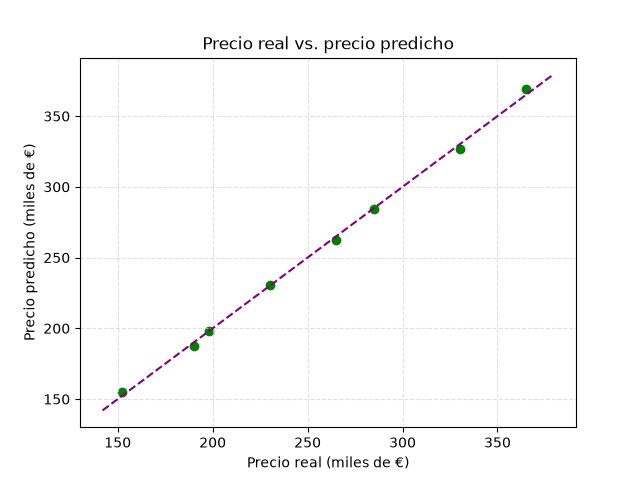

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
plt.xlabel('Precio real (miles de €)')
plt.ylabel('Precio predicho (miles de €)')
ax.grid(True, linestyle='--', color='lightgray', alpha=0.7)
ax.scatter(y, y_pred, c='green')
lims = [min(y.min(), y_pred.min()) - 10, max(y.max(), y_pred.max()) + 10]
_ = ax.plot(lims, lims, c='purple', linestyle='--') # línea y = x: predicción perfecta

Los puntos quedan cerca de la diagonal (precio real = precio predicho): el modelo lineal funciona razonablemente bien. Predecir el precio de una casa nueva es, de nuevo, un simple **producto punto** entre sus features y $w$:

In [8]:
x_new = np.array([1, 120, 4])  # 1 (bias), 120 m2, 4 habitaciones
print(f"Predicción: {np.dot(x_new, w):.2f} miles de €")

Predicción: 305.41 miles de €

## Otros Usos del Álgebra Lineal (sólo teoría)

Ya hemos resuelto un caso real de principio a fin (la regresión lineal). Para cerrar el tema, aquí tienes un repaso **puramente conceptual** — sin código — de otros sitios donde te vas a encontrar exactamente las mismas herramientas (vectores, matrices, normas, producto punto, inversión, matrices ortogonales) aplicadas a problemas distintos.

### PCA (Análisis de Componentes Principales)

**Dónde**: reducción de dimensionalidad — comprimir un dataset con muchas *features* en unas pocas que conserven la mayor parte de la información (visualización, eliminar ruido, acelerar otros modelos).

**Cómo**: se calcula la matriz de covarianza de los datos (una matriz siempre *simétrica*, como $X^TX$) y se obtienen sus **autovectores** (o, de forma equivalente y más estable, mediante la **SVD**, descomposición en valores singulares). Esos autovectores son **ortogonales entre sí** y marcan las direcciones de máxima varianza de los datos — exactamente el mismo concepto de matriz ortogonal que vimos en el Segmento 3.

### Redes Neuronales y Deep Learning

**Dónde**: la base de prácticamente todo el aprendizaje profundo (visión por computador, NLP, generación de imágenes/texto...).

**Cómo**: cada capa de una red no es más que una multiplicación de matrices seguida de una función no lineal: $z = Wx + b$ (el peso $W$ es una matriz, $x$ el vector de entrada, $b$ el vector de sesgos). Entrenar la red (*backpropagation*) consiste en calcular derivadas de estas operaciones matriciales y actualizar $W$ mediante descenso de gradiente — el mismo tipo de minimización que usamos con la ecuación normal, pero de forma iterativa en vez de resolverla de un tirón.

### Sistemas de Recomendación

**Dónde**: recomendar productos, películas o canciones (Netflix, Spotify, Amazon...).

**Cómo**: los datos se organizan como una gran matriz *usuario × producto* (muy dispersa, llena de huecos, ya que cada usuario sólo ha valorado unos pocos productos). Técnicas de **factorización de matrices** descomponen esa matriz en el producto de otras dos más pequeñas (matriz de usuarios y matriz de productos, cada fila/columna un vector de «gustos latentes»), y multiplicándolas se «rellenan» los huecos, es decir, se predice qué nota le pondría un usuario a algo que no ha visto.

### Procesamiento de Lenguaje Natural (NLP)

**Dónde**: buscadores, chatbots, traducción automática, los propios modelos como el que estás usando ahora.

**Cómo**: cada palabra (o trozo de palabra) se representa como un **vector** de cientos o miles de dimensiones (un *embedding*), de forma que palabras con significado parecido quedan cerca en ese espacio. La similitud entre dos palabras o frases se mide con el **producto escalar** (o, más exactamente, la similitud coseno, que es un producto escalar normalizado por las normas de los vectores).

### Gráficos por Computador, Videojuegos y Robótica

**Dónde**: mover, rotar y escalar objetos en una pantalla o en el espacio real (videojuegos, animación 3D, brazos robóticos, visión artificial).

**Cómo**: cada rotación, traslación o cambio de escala de un objeto se aplica multiplicando sus coordenadas (un vector o una matriz de puntos) por una **matriz de transformación**. Las rotaciones en particular se representan con **matrices ortogonales** — las mismas que vimos en el Segmento 3 —, precisamente porque no deforman el objeto: preservan distancias y ángulos.

### Compresión de Imágenes

**Dónde**: reducir el peso de una imagen o un vídeo conservando la mayor calidad visual posible.

**Cómo**: una imagen en escala de grises es, sencillamente, una **matriz** de píxeles. Aplicando la SVD a esa matriz se puede quedar sólo con sus componentes más importantes (una **aproximación de bajo rango**), descartando el resto — la misma idea que la norma de Frobenius que vimos, que sirve justo para medir cuánto «error» introduce esa aproximación respecto a la imagen original.

### Motores de Búsqueda

**Dónde**: ordenar los resultados de una búsqueda por relevancia — el algoritmo **PageRank** que hizo famoso a Google.

**Cómo**: la web se modela como una enorme matriz que representa qué páginas enlazan a qué otras páginas. La importancia de cada página resulta ser el **autovector principal** de esa matriz — de nuevo, el mismo tipo de cálculo que se usa en PCA, aplicado esta vez no a datos sino a la propia estructura de enlaces de internet.

---

El patrón se repite una y otra vez: **representar el problema como vectores/matrices → aplicar operaciones lineales (productos, normas, transposición, inversión) → resolver o minimizar algo**. Dominar bien lo visto en este notebook es, literalmente, la base para entender cualquiera de estas aplicaciones cuando las encuentres en detalle más adelante en la serie.

## Resumen: Lo Más Importante de Este Notebook

Una chuleta rápida con lo esencial, para repasar sin tener que releer todo el notebook.

### Los objetos básicos

* **Escalar** = tensor de rango 0 (un número). **Vector** = tensor de rango 1 (array de números). **Matriz** = tensor de rango 2 (filas × columnas).
* **Transposición** ($X^T$): intercambia filas por columnas. $(X^T)^T = X$.

### Normas (miden la magnitud de un vector)

| Norma | Fórmula | Se usa para... |
|---|---|---|
| $L^1$ | $\sum_i \lvert x_i \rvert$ | distinguir 0 de «casi 0»; regularización **Lasso** (dispersión) |
| $L^2$ (euclídea) | $\sqrt{\sum_i x_i^2}$ | la norma «por defecto»; distancia en línea recta |
| $L^2$ al cuadrado | $\sum_i x_i^2 = x^Tx$ | más barata; usada en el MSE y en **Ridge** |
| $L^\infty$ | $\max_i \lvert x_i \rvert$ | solo importa la componente más grande |

Y para **matrices** (no solo vectores): la **norma de Frobenius** $\|A\|_F=\sqrt{\sum_{i,j}A_{i,j}^2}$ — la misma idea que $L^2$, pero sumando sobre todos los elementos de la matriz. Muy usada para medir el «tamaño» del error entre una matriz y su aproximación (compresión de imágenes, PCA, SVD).

### Vectores especiales

* **Vector nulo** $\mathbf{0}$: todo ceros, no cambia nada al sumarlo.
* **Ortogonales**: $x\cdot y = 0$ (ángulo de 90°). **Ortonormales**: ortogonales + cada uno con norma 1.
* **Base**: vectores linealmente independientes que, combinados, generan cualquier vector del espacio.

### Operaciones con matrices

* **Escalar × matriz / suma**: se aplica a cada elemento.
* **Producto de Hadamard** ($A\odot B$): elemento a elemento; exige la misma forma en ambos tensores.
* **Producto escalar / punto** ($x\cdot y=\sum_i x_iy_i$): la operación que hace cada neurona de una red ($z=w\cdot x+b$).
* **Matriz × vector** y **matriz × matriz**: esta última **no es conmutativa** ($AB\neq BA$).

### Matrices especiales

* **Identidad** $I$: $Ix=x$, no transforma nada.
* **Simétrica**: $A=A^T$ (espejo respecto a la diagonal, no filas iguales).
* **Diagonal**: solo la diagonal es distinta de 0 — muy barata de multiplicar/invertir.
* **Ortogonal** $Q$: columnas ortonormales; su gran ventaja es que $Q^{-1}=Q^T$ (invertir = transponer, gratis).

### Inversión y sistemas lineales

* $AA^{-1}=A^{-1}A=I$. Solo existe si $A$ es cuadrada y sus columnas son linealmente independientes.
* Permite despejar $w$ en un sistema $Xw=y$: $w=X^{-1}y$.
* **Aplicación práctica** (la que resolvimos con regresión lineal): cuando el sistema no tiene solución exacta (más ecuaciones que incógnitas), se usa en su lugar la **ecuación normal** $w=(X^TX)^{-1}X^Ty$, que minimiza el error cuadrático total.